In [21]:
!pip install yfinance statsmodels --quiet

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import coint

plt.style.use("seaborn-v0_8-whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# Statistical Pairs Trading Strategy: Coca-Cola and PepsiCo

## Project Objective

This project develops and evaluates a statistical pairs-trading strategy using
historical stock-price data.

Several economically related pairs are initially tested for cointegration.
The KO–PEP pair is then selected for an exploratory out-of-sample backtest.

The strategy is based on the hypothesis that the spread between the log-prices
of two related assets may temporarily deviate from its historical equilibrium
and subsequently revert toward its mean.

## Methodology

The main steps are:

1. Download and explore adjusted stock-price data.
2. Separate the data into training and testing periods.
3. Test candidate pairs for cointegration.
4. Estimate the KO–PEP hedge ratio on the training period.
5. construct the spread and its z-score.
6. Generate long–short trading positions.
7. Perform an out-of-sample backtest without look-ahead bias.
8. Add transaction costs and a stop-loss mechanism.
9. Evaluate returns, volatility, Sharpe ratio and maximum drawdown.
10. Conduct a sensitivity analysis across different thresholds.

In [23]:
tickers = ["XOM", "CVX", "KO", "PEP", "JPM", "BAC", "GLD", "SLV"]

data = yf.download(
    tickers,
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

prices = data["Close"].dropna()

print(prices.head())
print("\nNumber of trading days and assets", prices.shape)

Ticker            BAC        CVX         GLD        JPM         KO        PEP  \
Date                                                                            
2018-01-02  24.385729  87.873619  125.150002  85.516029  34.816471  89.690933   
2018-01-03  24.304174  88.514168  124.820000  85.603180  34.740009  89.455391   
2018-01-04  24.622248  88.238686  125.459999  86.829498  35.229309  89.896027   
2018-01-05  24.736427  88.094009  125.330002  86.272087  35.221664  90.154343   
2018-01-08  24.565153  88.527946  125.309998  86.399483  35.168152  89.637749   

Ticker            SLV        XOM  
Date                              
2018-01-02  16.209999  57.811150  
2018-01-03  16.170000  58.946548  
2018-01-04  16.230000  59.028141  
2018-01-05  16.219999  58.980553  
2018-01-08  16.150000  59.245712  

Number of trading days and assets (2011, 8)


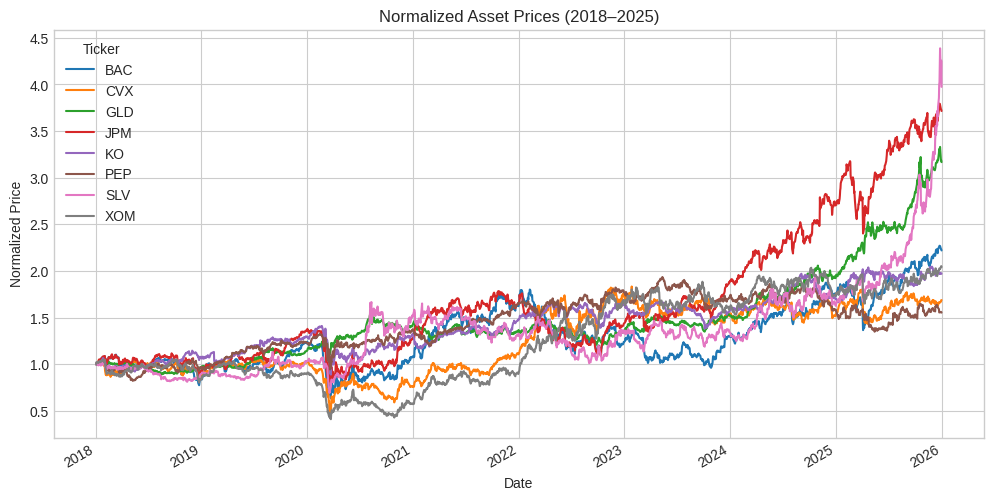

In [24]:
normalized_prices = prices / prices.iloc[0]

normalized_prices.plot(figsize=(12, 6))

plt.title("Normalized Asset Prices (2018–2025)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend(title="Ticker")
plt.show()

In [25]:
train_prices = prices.loc[:"2022-12-31"]
test_prices = prices.loc["2023-01-01":]

print("Training period:")
print(train_prices.index.min(), "to", train_prices.index.max())
print("Number of training observations:", len(train_prices))

print("\nTesting period:")
print(test_prices.index.min(), "to", test_prices.index.max())
print("Number of testing observations:", len(test_prices))

Training period:
2018-01-02 00:00:00 to 2022-12-30 00:00:00
Number of training observations: 1259

Testing period:
2023-01-03 00:00:00 to 2025-12-31 00:00:00
Number of testing observations: 752


In [26]:
candidate_pairs = [
    ("XOM", "CVX"),
    ("KO", "PEP"),
    ("JPM", "BAC"),
    ("GLD", "SLV")
]

log_train = np.log(train_prices)

results = []

for asset_1, asset_2 in candidate_pairs:
    test_statistic, p_value, critical_values = coint(
        log_train[asset_1],
        log_train[asset_2]
    )

    results.append({
        "Asset 1": asset_1,
        "Asset 2": asset_2,
        "Test statistic": test_statistic,
        "p-value": p_value
    })

cointegration_results = pd.DataFrame(results)
cointegration_results = cointegration_results.sort_values("p-value")

print(cointegration_results)

  Asset 1 Asset 2  Test statistic   p-value
1      KO     PEP       -3.290718  0.056021
0     XOM     CVX       -2.284119  0.381503
2     JPM     BAC       -2.018922  0.518729
3     GLD     SLV       -1.893623  0.583237


In [27]:
from statsmodels.tsa.stattools import adfuller

adf_results = []

for ticker in ["KO", "PEP"]:

    # ADF test on the log-price level
    level_test = adfuller(
        log_train[ticker].dropna(),
        autolag="AIC",
        result_object=False
    )

    # First difference of the log-price
    log_difference = log_train[ticker].diff().dropna()

    # ADF test on the first-differenced log-price
    difference_test = adfuller(
        log_difference,
        autolag="AIC",
        result_object=False
    )

    adf_results.append({
        "Asset": ticker,
        "Level p-value": level_test[1],
        "First-difference p-value": difference_test[1]
    })

integration_results = pd.DataFrame(adf_results)

print(integration_results)

  Asset  Level p-value  First-difference p-value
0    KO       0.738902              6.689057e-20
1   PEP       0.829710              1.171672e-18


Alpha: 0.1904864685124188
Beta: 0.7561717344733222

Spread summary:
count    1.259000e+03
mean    -2.300375e-14
std      4.798676e-02
min     -1.764471e-01
25%     -3.060280e-02
50%      2.506319e-03
75%      3.737561e-02
max      9.603814e-02
dtype: float64


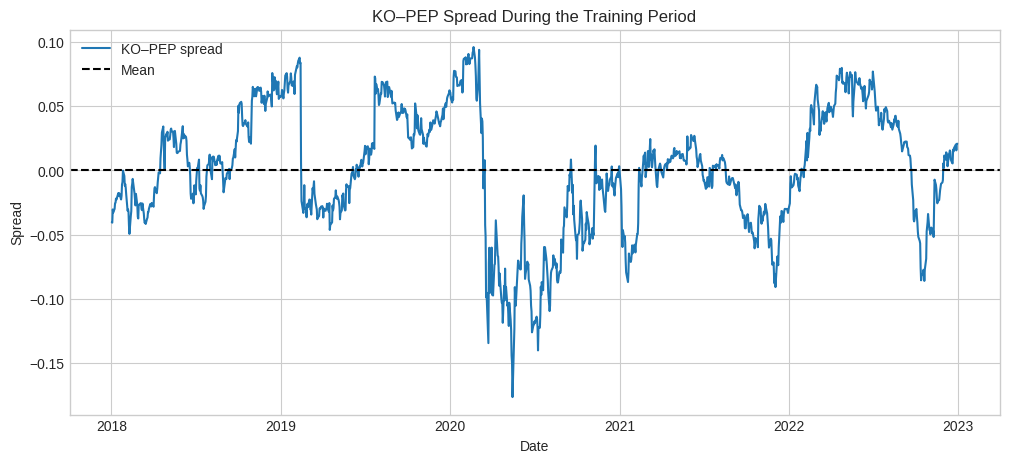

In [28]:
import statsmodels.api as sm

# Regression variables
y_train = log_train["KO"]
x_train = log_train["PEP"]

# Add a constant column to estimate alpha
X_train = sm.add_constant(x_train)

# Estimate: log(KO) = alpha + beta * log(PEP) + error
model = sm.OLS(y_train, X_train).fit()

alpha = model.params["const"]
beta = model.params["PEP"]

# Construct the spread
spread_train = y_train - alpha - beta * x_train

print("Alpha:", alpha)
print("Beta:", beta)
print("\nSpread summary:")
print(spread_train.describe())

# Plot the spread
plt.figure(figsize=(12, 5))
plt.plot(spread_train, label="KO–PEP spread")

plt.axhline(
    spread_train.mean(),
    color="black",
    linestyle="--",
    label="Mean"
)

plt.title("KO–PEP Spread During the Training Period")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.show()

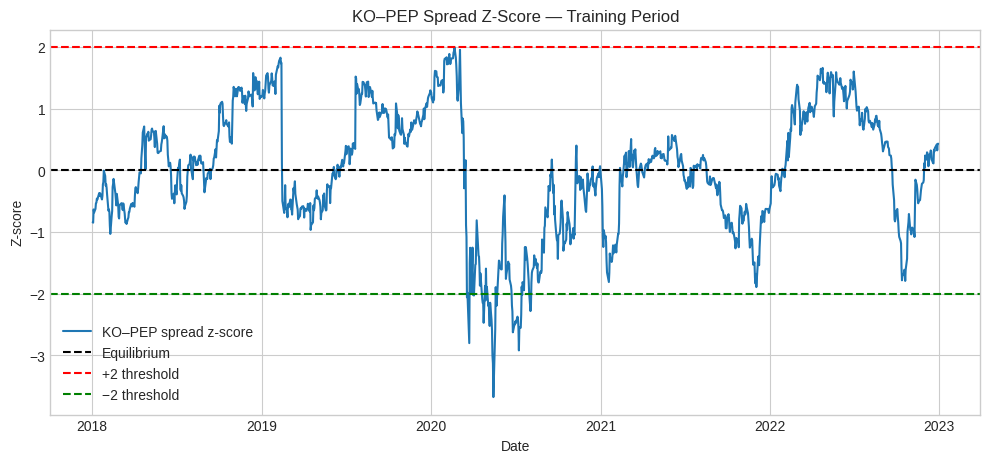

In [29]:
spread_mean = spread_train.mean()

spread_std = spread_train.std()

zscore_train = (spread_train - spread_mean) / spread_std

plt.figure(figsize=(12, 5))

plt.plot(
    zscore_train,
    label="KO–PEP spread z-score"
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    label="Equilibrium"
)

plt.axhline(
    2,
    color="red",
    linestyle="--",
    label="+2 threshold"
)

plt.axhline(
    -2,
    color="green",
    linestyle="--",
    label="−2 threshold"
)

plt.title("KO–PEP Spread Z-Score — Training Period")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.show()

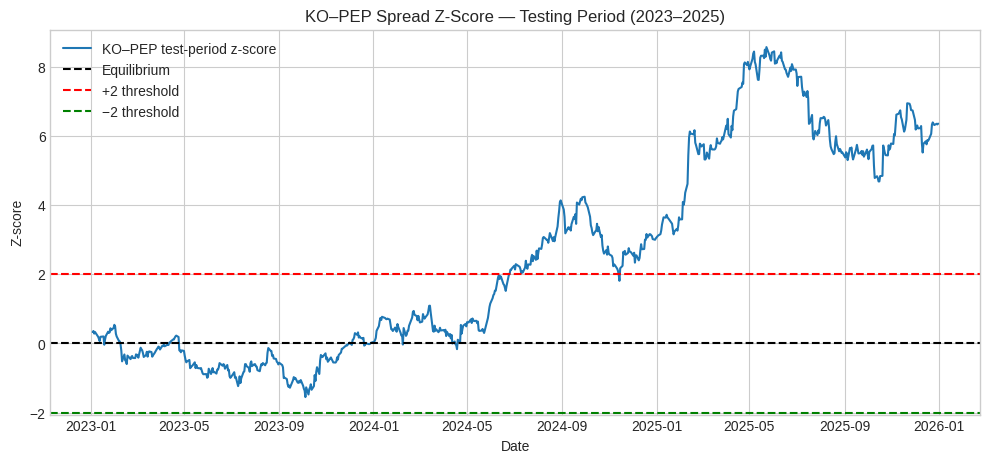

In [30]:
# Log-prices for the testing period
log_test = np.log(test_prices)

# Testing-period spread using alpha and beta
# estimated on the 2018–2022 training period
spread_test = (
    log_test["KO"]
    - alpha
    - beta * log_test["PEP"]
)

# Testing-period z-score using the training-period
# spread mean and standard deviation
zscore_test = (
    spread_test - spread_mean
) / spread_std

# Plot the testing-period z-score
plt.figure(figsize=(12, 5))

plt.plot(
    zscore_test,
    label="KO–PEP test-period z-score"
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    label="Equilibrium"
)

plt.axhline(
    2,
    color="red",
    linestyle="--",
    label="+2 threshold"
)

plt.axhline(
    -2,
    color="green",
    linestyle="--",
    label="−2 threshold"
)

plt.title("KO–PEP Spread Z-Score — Testing Period (2023–2025)")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.show()

Position
-1    382
 0    370
Name: count, dtype: int64


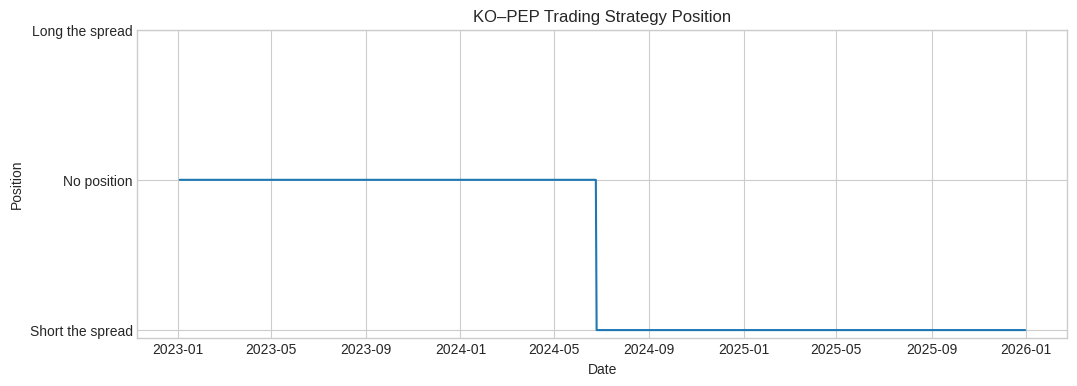

In [31]:
positions = []

current_position = 0

for z in zscore_test:

    # No trade is currently open
    if current_position == 0:

        # Spread is too high: short KO and buy PEP
        if z >= 2:
            current_position = -1

        # Spread is too low: buy KO and short PEP
        elif z <= -2:
            current_position = 1

    # The strategy is long the spread
    elif current_position == 1:

        # The spread has returned to equilibrium
        if z >= 0:
            current_position = 0

    # The strategy is short the spread
    elif current_position == -1:

        # The spread has returned to equilibrium
        if z <= 0:
            current_position = 0

    positions.append(current_position)

positions = pd.Series(
    positions,
    index=zscore_test.index,
    name="Position"
)

print(positions.value_counts().sort_index())

plt.figure(figsize=(12, 4))
plt.plot(positions)

plt.title("KO–PEP Trading Strategy Position")
plt.xlabel("Date")
plt.ylabel("Position")

plt.yticks(
    [-1, 0, 1],
    ["Short the spread", "No position", "Long the spread"]
)

plt.show()

## Preliminary Backtest Using Log-Returns

This first backtest evaluates the strategy using a weighted combination of the daily log-returns of KO and PEP.Log-returns are useful because they are additive over time, which makescumulative performance easy to calculate.
However,a weighted combination of individual asset log-returns is only anapproximation of the return of a rebalanced long-short portfolio. Therefore, this calculation is retained as a preliminary analysis and for comparison with the final backtest based on simple returns.

Total return: -11.20%
Final value of an initial capital of 1: 0.8880


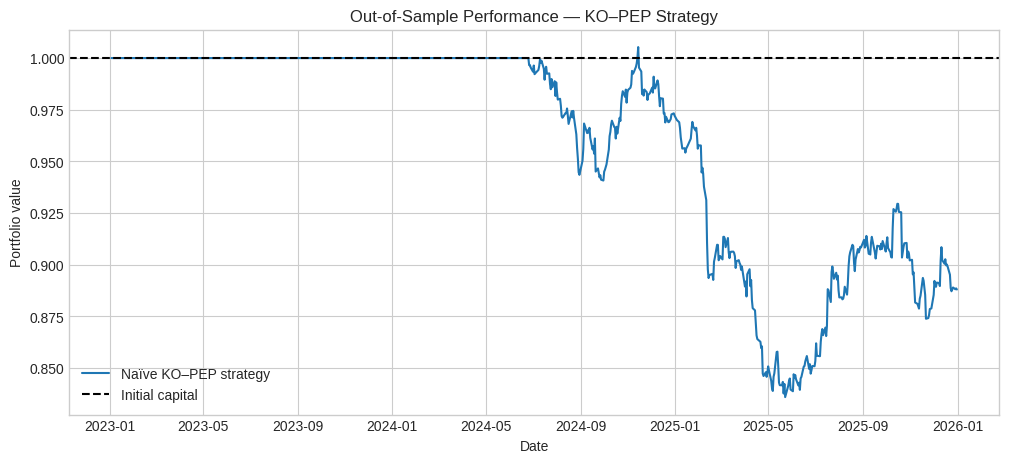

In [32]:
# Daily changes in log-prices
ko_log_return = log_test["KO"].diff()
pep_log_return = log_test["PEP"].diff()

# Daily change in the spread
spread_return = (
    ko_log_return
    - beta * pep_log_return
)

# Normalize by the total gross exposure
spread_return = spread_return / (1 + abs(beta))

# Daily strategy return
strategy_return = (
    positions.shift(1)
    * spread_return
).fillna(0)

# Evolution of an initial capital of 1
wealth = np.exp(strategy_return.cumsum())

# Total return
total_return = wealth.iloc[-1] - 1

print(f"Total return: {total_return:.2%}")
print(f"Final value of an initial capital of 1: {wealth.iloc[-1]:.4f}")

# Plot the portfolio value
plt.figure(figsize=(12, 5))

plt.plot(
    wealth,
    label="Naïve KO–PEP strategy"
)

plt.axhline(
    1,
    color="black",
    linestyle="--",
    label="Initial capital"
)

plt.title("Out-of-Sample Performance — KO–PEP Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.legend()
plt.show()

## Adding a Stop-Loss

The naïve strategy assumes that the spread will eventually return to equilibrium. However, the spread may continue moving away from zero.
A stop-loss mechanism is therefore introduced to close the position when the z-score reaches an extreme level. After a stop-loss, the strategy remains inactive until the z-score returns to the normal range.
In this section, performance is still evaluated using the preliminary log-return approximation.

Naïve strategy: -11.20%
Strategy with stop-loss: -4.36%


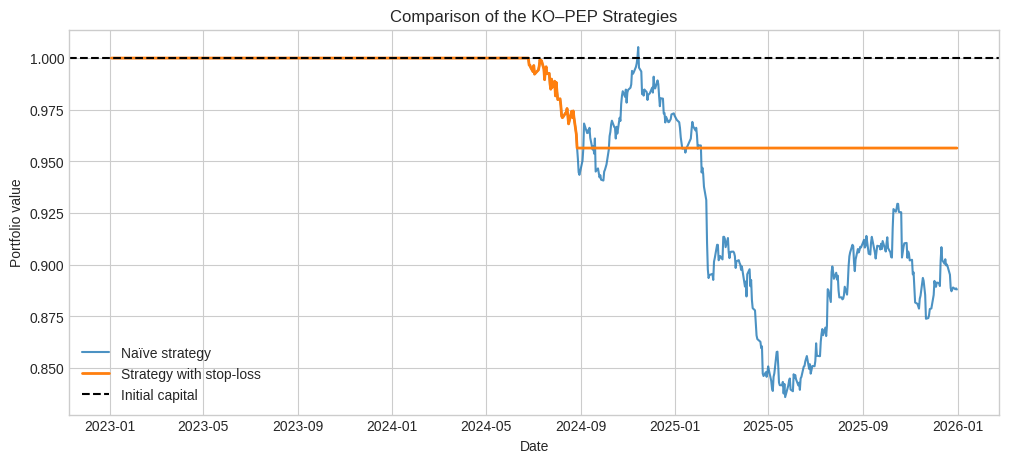

In [33]:
risk_positions = []

current_position = 0
blocked = False

for z in zscore_test:

    # After a stop-loss, wait for the z-score
    # to return to the normal range
    if blocked:
        current_position = 0

        if abs(z) < 1:
            blocked = False

    # The strategy is allowed to trade
    else:

        # No open position
        if current_position == 0:

            # Spread is too high: short KO and buy PEP
            if z >= 2:
                current_position = -1

            # Spread is too low: buy KO and short PEP
            elif z <= -2:
                current_position = 1

        # The strategy is long the spread
        elif current_position == 1:

            # Normal exit: the spread returns to equilibrium
            if z >= 0:
                current_position = 0

            # Stop-loss: the spread continues to fall
            elif z <= -3.5:
                current_position = 0
                blocked = True

        # The strategy is short the spread
        elif current_position == -1:

            # Normal exit: the spread returns to equilibrium
            if z <= 0:
                current_position = 0

            # Stop-loss: the spread continues to rise
            elif z >= 3.5:
                current_position = 0
                blocked = True

    risk_positions.append(current_position)

risk_positions = pd.Series(
    risk_positions,
    index=zscore_test.index,
    name="Risk-managed position"
)

# Returns of the strategy with a stop-loss
risk_strategy_return = (
    risk_positions.shift(1) * spread_return
).fillna(0)

# Evolution of the portfolio value
risk_wealth = np.exp(
    risk_strategy_return.cumsum()
)

# Total return
risk_total_return = risk_wealth.iloc[-1] - 1

print(f"Naïve strategy: {total_return:.2%}")
print(f"Strategy with stop-loss: {risk_total_return:.2%}")

# Performance comparison
plt.figure(figsize=(12, 5))

plt.plot(
    wealth,
    label="Naïve strategy",
    alpha=0.8
)

plt.plot(
    risk_wealth,
    label="Strategy with stop-loss",
    linewidth=2
)

plt.axhline(
    1,
    color="black",
    linestyle="--",
    label="Initial capital"
)

plt.title("Comparison of the KO–PEP Strategies")
plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.legend()
plt.show()

## Final Backtest Using Simple Returns
The previous log-return calculation provided a preliminary approximation.For
the final performance evaluation, simple daily returns are used. They make it possible to construct explicitly the daily return of the normalized long-short portfolio.
Portfolio wealth is calculated by compounding the daily returns:
\[
W_t = W_{t-1}(1+r_t).
\]
All final performance metrics, transaction costs, drawdowns, Sharpe ratios,sensitivity results reported below are based on this simple-return backtest.

Naïve strategy: -11.47%
Strategy with stop-loss: -4.39%


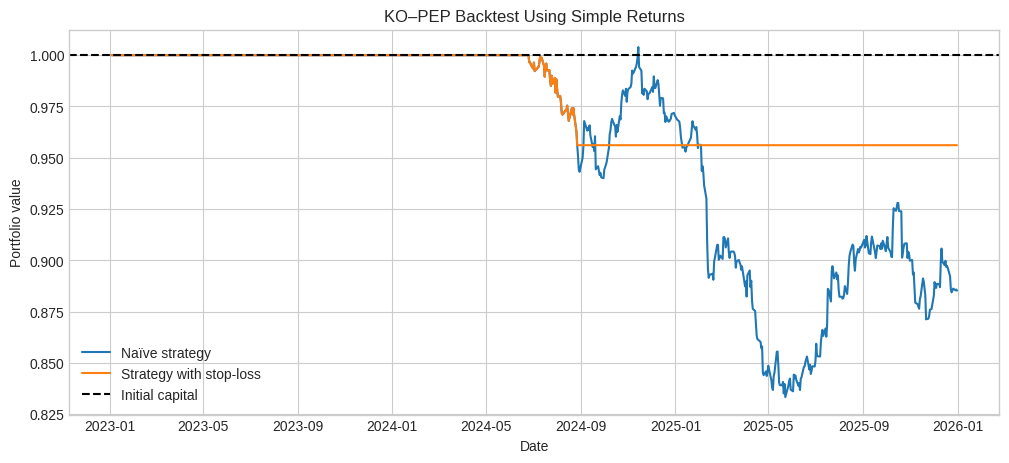

In [34]:
# 1. Daily simple returns
simple_returns = test_prices[["KO", "PEP"]].pct_change()

ko_return = simple_returns["KO"]
pep_return = simple_returns["PEP"]

# 2. KO–PEP portfolio return
portfolio_return = (
    ko_return - beta * pep_return
) / (1 + abs(beta))

# 3. Returns of both strategies
naive_return = (
    positions.shift(1) * portfolio_return
).fillna(0)

stop_loss_return = (
    risk_positions.shift(1) * portfolio_return
).fillna(0)

# 4. Evolution of the portfolio values
naive_wealth = (1 + naive_return).cumprod()
stop_loss_wealth = (1 + stop_loss_return).cumprod()

# 5. Total returns
naive_total_return = naive_wealth.iloc[-1] - 1
stop_loss_total_return = stop_loss_wealth.iloc[-1] - 1

print(f"Naïve strategy: {naive_total_return:.2%}")
print(f"Strategy with stop-loss: {stop_loss_total_return:.2%}")

# 6. Performance comparison
plt.figure(figsize=(12, 5))

plt.plot(
    naive_wealth,
    label="Naïve strategy"
)

plt.plot(
    stop_loss_wealth,
    label="Strategy with stop-loss"
)

plt.axhline(
    1,
    color="black",
    linestyle="--",
    label="Initial capital"
)

plt.title("KO–PEP Backtest Using Simple Returns")
plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.legend()
plt.show()

Naïve strategy after transaction costs: -11.56%
Strategy with stop-loss after transaction costs: -4.58%
Number of naïve-strategy entries: 1
Number of stop-loss-strategy entries: 1


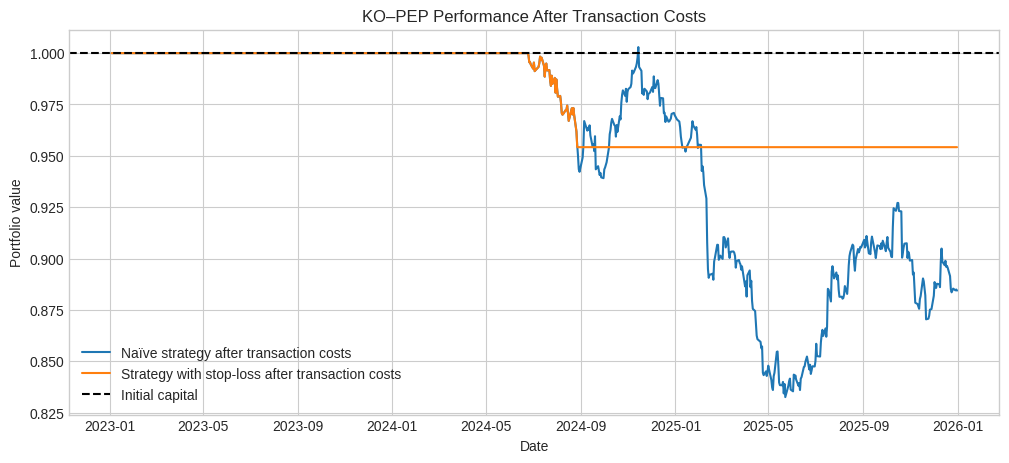

In [35]:
# Assumed transaction cost per unit of portfolio turnover
transaction_cost_rate = 0.001  # 0.10%

# Changes in position
naive_turnover = positions.diff().abs().fillna(0)
stop_loss_turnover = risk_positions.diff().abs().fillna(0)

# Daily transaction costs
naive_costs = transaction_cost_rate * naive_turnover
stop_loss_costs = transaction_cost_rate * stop_loss_turnover

# Returns after transaction costs
naive_return_net = naive_return - naive_costs
stop_loss_return_net = stop_loss_return - stop_loss_costs

# Portfolio values after transaction costs
naive_wealth_net = (1 + naive_return_net).cumprod()
stop_loss_wealth_net = (1 + stop_loss_return_net).cumprod()

# Total returns after transaction costs
naive_total_net = naive_wealth_net.iloc[-1] - 1
stop_loss_total_net = stop_loss_wealth_net.iloc[-1] - 1

# Number of opened positions
naive_entries = (
    (positions != 0)
    & (positions.shift(1).fillna(0) == 0)
).sum()

stop_loss_entries = (
    (risk_positions != 0)
    & (risk_positions.shift(1).fillna(0) == 0)
).sum()

print(f"Naïve strategy after transaction costs: {naive_total_net:.2%}")
print(
    f"Strategy with stop-loss after transaction costs: "
    f"{stop_loss_total_net:.2%}"
)
print(f"Number of naïve-strategy entries: {naive_entries}")
print(f"Number of stop-loss-strategy entries: {stop_loss_entries}")

# Plot portfolio performance
plt.figure(figsize=(12, 5))

plt.plot(
    naive_wealth_net,
    label="Naïve strategy after transaction costs"
)

plt.plot(
    stop_loss_wealth_net,
    label="Strategy with stop-loss after transaction costs"
)

plt.axhline(
    1,
    color="black",
    linestyle="--",
    label="Initial capital"
)

plt.title("KO–PEP Performance After Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.legend()
plt.show()

In [36]:
# Average number of trading days per year
TRADING_DAYS = 252


def calculate_metrics(daily_returns, wealth, number_of_entries):
    """
    Calculate the main performance metrics
    of a trading strategy.
    """

    # Number of observed trading days
    number_of_days = len(daily_returns)

    # Total return over the entire period
    total_return = wealth.iloc[-1] - 1

    # Annualized return
    annualized_return = (
        wealth.iloc[-1] ** (TRADING_DAYS / number_of_days)
        - 1
    )

    # Annualized volatility
    annualized_volatility = (
        daily_returns.std() * np.sqrt(TRADING_DAYS)
    )

    # Sharpe ratio, assuming a zero risk-free rate
    if daily_returns.std() != 0:
        sharpe_ratio = (
            daily_returns.mean()
            / daily_returns.std()
            * np.sqrt(TRADING_DAYS)
        )
    else:
        sharpe_ratio = np.nan

    # Highest portfolio value reached up to each date
    running_maximum = wealth.cummax()

    # Decline from the most recent portfolio peak
    drawdown = wealth / running_maximum - 1

    # Largest observed decline
    maximum_drawdown = drawdown.min()

    return {
        "Total return": total_return,
        "Annualized return": annualized_return,
        "Annualized volatility": annualized_volatility,
        "Sharpe ratio": sharpe_ratio,
        "Maximum drawdown": maximum_drawdown,
        "Number of trades": number_of_entries
    }


# Naïve-strategy metrics
naive_metrics = calculate_metrics(
    naive_return_net,
    naive_wealth_net,
    naive_entries
)

# Stop-loss-strategy metrics
stop_loss_metrics = calculate_metrics(
    stop_loss_return_net,
    stop_loss_wealth_net,
    stop_loss_entries
)

# Comparison table
metrics_table = pd.DataFrame(
    {
        "Naïve strategy": naive_metrics,
        "Strategy with stop-loss": stop_loss_metrics
    }
)

# Create a display version that can contain formatted strings
formatted_table = metrics_table.copy().astype(object)

for row in [
    "Total return",
    "Annualized return",
    "Annualized volatility",
    "Maximum drawdown"
]:
    formatted_table.loc[row] = (
        metrics_table.loc[row]
        .astype(float)
        .map(lambda x: f"{x:.2%}")
    )

formatted_table.loc["Sharpe ratio"] = (
    metrics_table.loc["Sharpe ratio"]
    .astype(float)
    .map(lambda x: f"{x:.2f}")
)

formatted_table.loc["Number of trades"] = (
    metrics_table.loc["Number of trades"]
    .astype(int)
    .astype(str)
)

print(formatted_table)

                      Naïve strategy Strategy with stop-loss
Total return                 -11.56%                  -4.58%
Annualized return             -4.03%                  -1.56%
Annualized volatility          5.92%                   1.46%
Sharpe ratio                   -0.67                   -1.07
Maximum drawdown             -16.99%                  -4.58%
Number of trades                   1                       1


In [37]:
def generate_risk_positions(
    z_scores,
    entry_threshold,
    stop_threshold,
    reentry_threshold=1
):
    """
    Generate the positions of a trading strategy with:
    - an entry threshold;
    - an exit when the z-score returns to zero;
    - a stop-loss;
    - a re-entry block after the stop-loss is triggered.
    """

    generated_positions = []

    current_position = 0
    blocked = False

    for z in z_scores:

        # After a stop-loss, do not open a new position
        # until the z-score has returned close to zero
        if blocked:

            current_position = 0

            if abs(z) < reentry_threshold:
                blocked = False

        else:

            # No position is currently open
            if current_position == 0:

                # Spread is too high: short the spread
                if z >= entry_threshold:
                    current_position = -1

                # Spread is too low: go long the spread
                elif z <= -entry_threshold:
                    current_position = 1

            # The strategy is long the spread
            elif current_position == 1:

                # Normal exit: the spread returns to equilibrium
                if z >= 0:
                    current_position = 0

                # Stop-loss: the spread continues to fall
                elif z <= -stop_threshold:
                    current_position = 0
                    blocked = True

            # The strategy is short the spread
            elif current_position == -1:

                # Normal exit: the spread returns to equilibrium
                if z <= 0:
                    current_position = 0

                # Stop-loss: the spread continues to rise
                elif z >= stop_threshold:
                    current_position = 0
                    blocked = True

        generated_positions.append(current_position)

    return pd.Series(
        generated_positions,
        index=z_scores.index
    )

In [38]:
# Parameter values to test
entry_thresholds = [1.5, 2.0, 2.5]
stop_thresholds = [3.0, 3.5, 4.0]

sensitivity_results = []

for entry_threshold in entry_thresholds:

    for stop_threshold in stop_thresholds:

        # Generate the trading positions
        test_positions = generate_risk_positions(
            zscore_test,
            entry_threshold=entry_threshold,
            stop_threshold=stop_threshold
        )

        # Gross strategy return
        test_return_gross = (
            test_positions.shift(1) * portfolio_return
        ).fillna(0)

        # Changes in position
        test_turnover = (
            test_positions.diff()
            .abs()
            .fillna(0)
        )

        # Strategy return after transaction costs
        test_return_net = (
            test_return_gross
            - transaction_cost_rate * test_turnover
        )

        # Evolution of the portfolio value
        test_wealth = (
            1 + test_return_net
        ).cumprod()

        # Total return
        test_total_return = test_wealth.iloc[-1] - 1

        # Maximum drawdown
        test_running_maximum = test_wealth.cummax()

        test_drawdown = (
            test_wealth / test_running_maximum - 1
        )

        test_maximum_drawdown = test_drawdown.min()

        # Number of opened positions
        test_entries = (
            (test_positions != 0)
            & (test_positions.shift(1).fillna(0) == 0)
        ).sum()

        # Store the results
        sensitivity_results.append({
            "Entry threshold": entry_threshold,
            "Stop-loss threshold": stop_threshold,
            "Total return": test_total_return,
            "Maximum drawdown": test_maximum_drawdown,
            "Number of trades": test_entries
        })


# Create the results table
sensitivity_table = pd.DataFrame(sensitivity_results)

# Create a readable display version
sensitivity_display = sensitivity_table.copy()

sensitivity_display["Total return"] = (
    sensitivity_display["Total return"]
    .map(lambda x: f"{x:.2%}")
)

sensitivity_display["Maximum drawdown"] = (
    sensitivity_display["Maximum drawdown"]
    .map(lambda x: f"{x:.2%}")
)

print(sensitivity_display)

   Entry threshold  Stop-loss threshold Total return Maximum drawdown  \
0              1.5                  3.0       -0.27%           -4.29%   
1              1.5                  3.5       -1.88%           -5.83%   
2              1.5                  4.0       -3.08%           -6.98%   
3              2.0                  3.0       -3.02%           -3.02%   
4              2.0                  3.5       -4.58%           -4.58%   
5              2.0                  4.0       -5.75%           -5.75%   
6              2.5                  3.0       -1.55%           -1.94%   
7              2.5                  3.5       -3.13%           -3.52%   
8              2.5                  4.0       -4.32%           -4.70%   

   Number of trades  
0                 2  
1                 2  
2                 2  
3                 1  
4                 1  
5                 1  
6                 1  
7                 1  
8                 1  


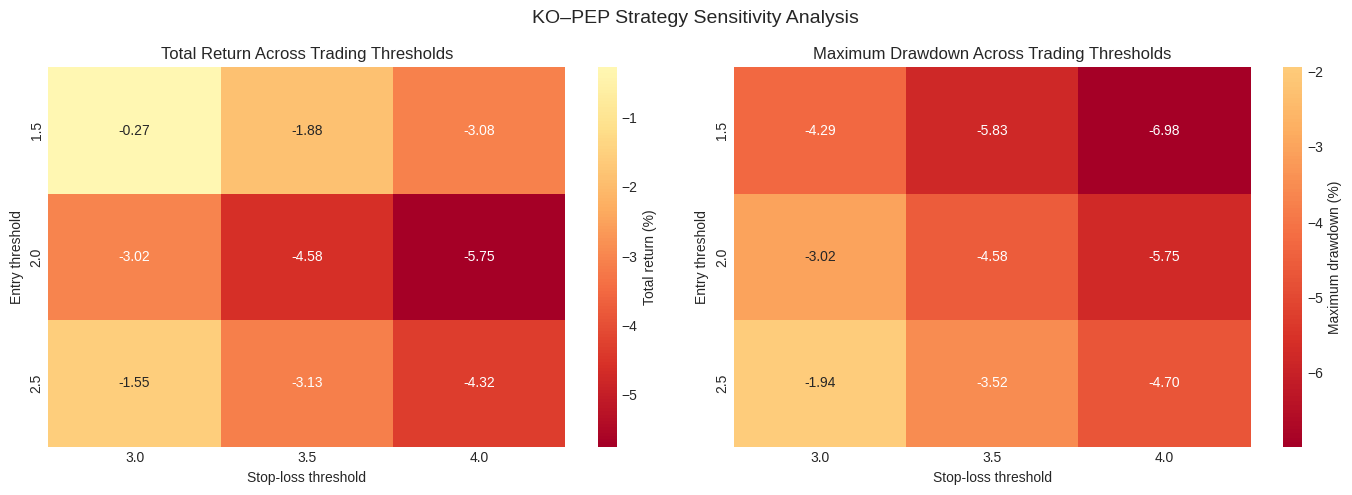

In [39]:
import seaborn as sns

# Total-return table in percentage points
return_heatmap = sensitivity_table.pivot(
    index="Entry threshold",
    columns="Stop-loss threshold",
    values="Total return"
) * 100

# Maximum-drawdown table in percentage points
drawdown_heatmap = sensitivity_table.pivot(
    index="Entry threshold",
    columns="Stop-loss threshold",
    values="Maximum drawdown"
) * 100

# Create two charts side by side
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Total-return heatmap
sns.heatmap(
    return_heatmap,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    ax=axes[0],
    cbar_kws={"label": "Total return (%)"}
)

axes[0].set_title(
    "Total Return Across Trading Thresholds"
)
axes[0].set_xlabel("Stop-loss threshold")
axes[0].set_ylabel("Entry threshold")

# Maximum-drawdown heatmap
sns.heatmap(
    drawdown_heatmap,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    ax=axes[1],
    cbar_kws={"label": "Maximum drawdown (%)"}
)

axes[1].set_title(
    "Maximum Drawdown Across Trading Thresholds"
)
axes[1].set_xlabel("Stop-loss threshold")
axes[1].set_ylabel("Entry threshold")

plt.suptitle(
    "KO–PEP Strategy Sensitivity Analysis",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Conclusion and Key Takeaways

The initial idea behind this project was simple: if two economically related companies such as Coca-Cola and PepsiCo tend to move together over time, a temporary divergence between their prices might create a trading opportunity. However, implementing this idea showed me that pairs trading is much more subtle than simply identifying two correlated stocks.

The first important distinction I learned was between correlation and cointegration. Correlation indicates whether two assets tend to move in the same direction, but it does not guarantee that the distance between them will return to a stable level. Cointegration is more relevant for pairs trading because it asks whether a particular combination of the two price series—the spread—behaves like a stationary process and tends to return toward an equilibrium.

Using data from 2018 to 2022, I tested four economically related pairs. KO–PEP produced the lowest Engle–Granger p-value, approximately 0.056. This was not sufficient to reject the absence of cointegration at the conventional 5% level, although it provided borderline evidence at the 10% level. I therefore selected KO–PEP as an exploratory pair while keeping in mind that the statistical evidence was not particularly strong.

I estimated the relationship between the two log-prices on the training period and constructed the spread

$$
S_t=\log(P_t^{KO})-\alpha-\beta\log(P_t^{PEP}).
$$

The z-score then allowed me to express the spread’s distance from its historical mean in units of standard deviation. A large positive z-score suggested that KO was relatively expensive compared with PEP, leading the strategy to short KO and buy PEP in anticipation of a decrease in the spread. A large negative z-score would generate the opposite position.

One of the most important methodological choices was to separate the data chronologically. All model parameters—including the hedge ratio, the spread mean and its standard deviation—were estimated using only the 2018–2022 training period. The 2023–2025 data were then treated as genuinely unseen observations. I also shifted the positions by one day in the backtest, because a signal calculated using today’s closing prices cannot be used to earn the price movement that has already occurred during the same day. This prevented look-ahead bias.

The out-of-sample results did not follow the mean-reversion scenario that I initially expected. From 2024 onward, the KO–PEP z-score rose above the entry threshold and continued increasing, eventually reaching extremely high levels instead of returning toward zero. The strategy therefore shorted KO and bought PEP, but KO continued to outperform PEP. What initially appeared to be a temporary deviation became a persistent change in the relationship between the two stocks.

Using simple asset returns, a normalized long–short portfolio and transaction costs of 0.10% per unit of turnover, the naïve strategy generated a total return of −11.56%. Its annualized return was −4.03%, its annualized volatility was 5.92%, and its maximum drawdown reached −16.99%.

I then added a stop-loss to close the position when the z-score reached 3.5 and prevented immediate re-entry until the spread moved closer to its historical equilibrium. This reduced the final loss to −4.58%, the annualized volatility to 1.46%, and the maximum drawdown to −4.58%. The stop-loss did not make the strategy profitable, but it prevented the strategy from continuing to bet on a relationship that was no longer behaving as expected.

The sensitivity analysis reinforced this conclusion. I tested entry thresholds of 1.5, 2.0 and 2.5 together with stop-loss thresholds of 3.0, 3.5 and 4.0. All nine combinations produced negative returns. Tighter stop-loss levels generally reduced both the losses and the drawdowns, but changing the thresholds did not restore profitability. I deliberately did not select the best-performing combination as a new “optimal” strategy, because doing so after observing the test results would amount to tuning the model on the test set.

The negative performance is therefore not a failure of the project. On the contrary, it illustrates one of its main lessons: a statistical relationship observed historically is not a permanent economic law. A pair may appear cointegrated during one period and then experience a structural change. Risk-management rules can limit the resulting losses, but they cannot create mean reversion when the underlying relationship has broken down.

This project also taught me that evaluating a trading strategy requires more than looking at its final return. Transaction costs, volatility, maximum drawdown, the timing of signals, out-of-sample testing and the number of independent trades all matter. In this experiment, only one or two trades were generated depending on the thresholds, so metrics such as the Sharpe ratio must be interpreted cautiously.

Several improvements could be investigated in future work: estimating the hedge ratio on a rolling window, periodically retesting cointegration, adding a maximum holding period, monitoring structural breaks, accounting for short-borrowing costs, and screening a larger universe of stocks with appropriate multiple-testing corrections.

Overall, the project demonstrates both the appeal and the limitations of statistical pairs trading. The strategy was based on a mathematically meaningful hypothesis, implemented without using future information, evaluated after realistic transaction costs, and tested under several parameter choices. Most importantly, the out-of-sample failure was preserved and analyzed rather than hidden through retrospective parameter optimization.
